In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image

In [2]:
class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    observation : str

In [3]:
def calc_bmi(state:BMIState)->BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/height**2
    state['bmi'] = bmi
    return state

In [4]:
def obs(state:BMIState)->BMIState:
    bmi = state['bmi']
    if bmi<18.5:
        state['observation'] = "Underweight"
    elif 18.5<=bmi<25:
        state['observation'] = "Normal"
    elif 25<=bmi<30:
        state['observation'] = "Overweight"
    elif 30<bmi:
        state['observation'] = "Obese"

    return state

In [5]:
graph = StateGraph(BMIState)

graph.add_node('calc_bmi',calc_bmi)
graph.add_node('obs',obs)

graph.add_edge(START,'calc_bmi')
graph.add_edge('calc_bmi','obs')
graph.add_edge('obs',END)

workflow = graph.compile()

In [6]:
result = workflow.invoke({"weight_kg":70,"height_m":1.74})

In [7]:
result

{'weight_kg': 70,
 'height_m': 1.74,
 'bmi': 23.120623596247853,
 'observation': 'Normal'}

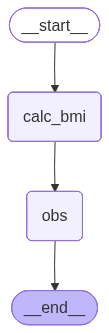

In [8]:
Image(workflow.get_graph().draw_mermaid_png())